In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv
from pathlib import Path

#plotting setup
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")
%matplotlib inline

# Paths
PROJECT_ROOT = Path("..").resolve()
GEO_DIR = PROJECT_ROOT / "data" / "geospatial"

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:

load_dotenv(PROJECT_ROOT / ".env")
DB_HOST = os.getenv("DB_HOST", "localhost")
DB_PORT = os.getenv("DB_PORT", "5432")
DB_NAME = os.getenv("DB_NAME", "nfhs_health_analytics")
DB_USER = os.getenv("DB_USER", "postgres")
DB_PASSWORD = os.getenv("DB_PASSWORD", "")

conn_string = f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
engine = create_engine(conn_string)

# Load data from PostgreSQL
df_wide = pd.read_sql("SELECT * FROM nfhs.district_health_wide", engine)
df_long = pd.read_sql("SELECT * FROM nfhs.fact_health_long", engine)

# Analytical Views
df_composite = pd.read_sql("SELECT * FROM nfhs.vw_district_health_score", engine)
df_nutrition = pd.read_sql("SELECT * FROM nfhs.vw_child_nutrition", engine)

print(f"Loaded {len(df_wide)} districts for analysis.")

Loaded 647 districts for analysis.


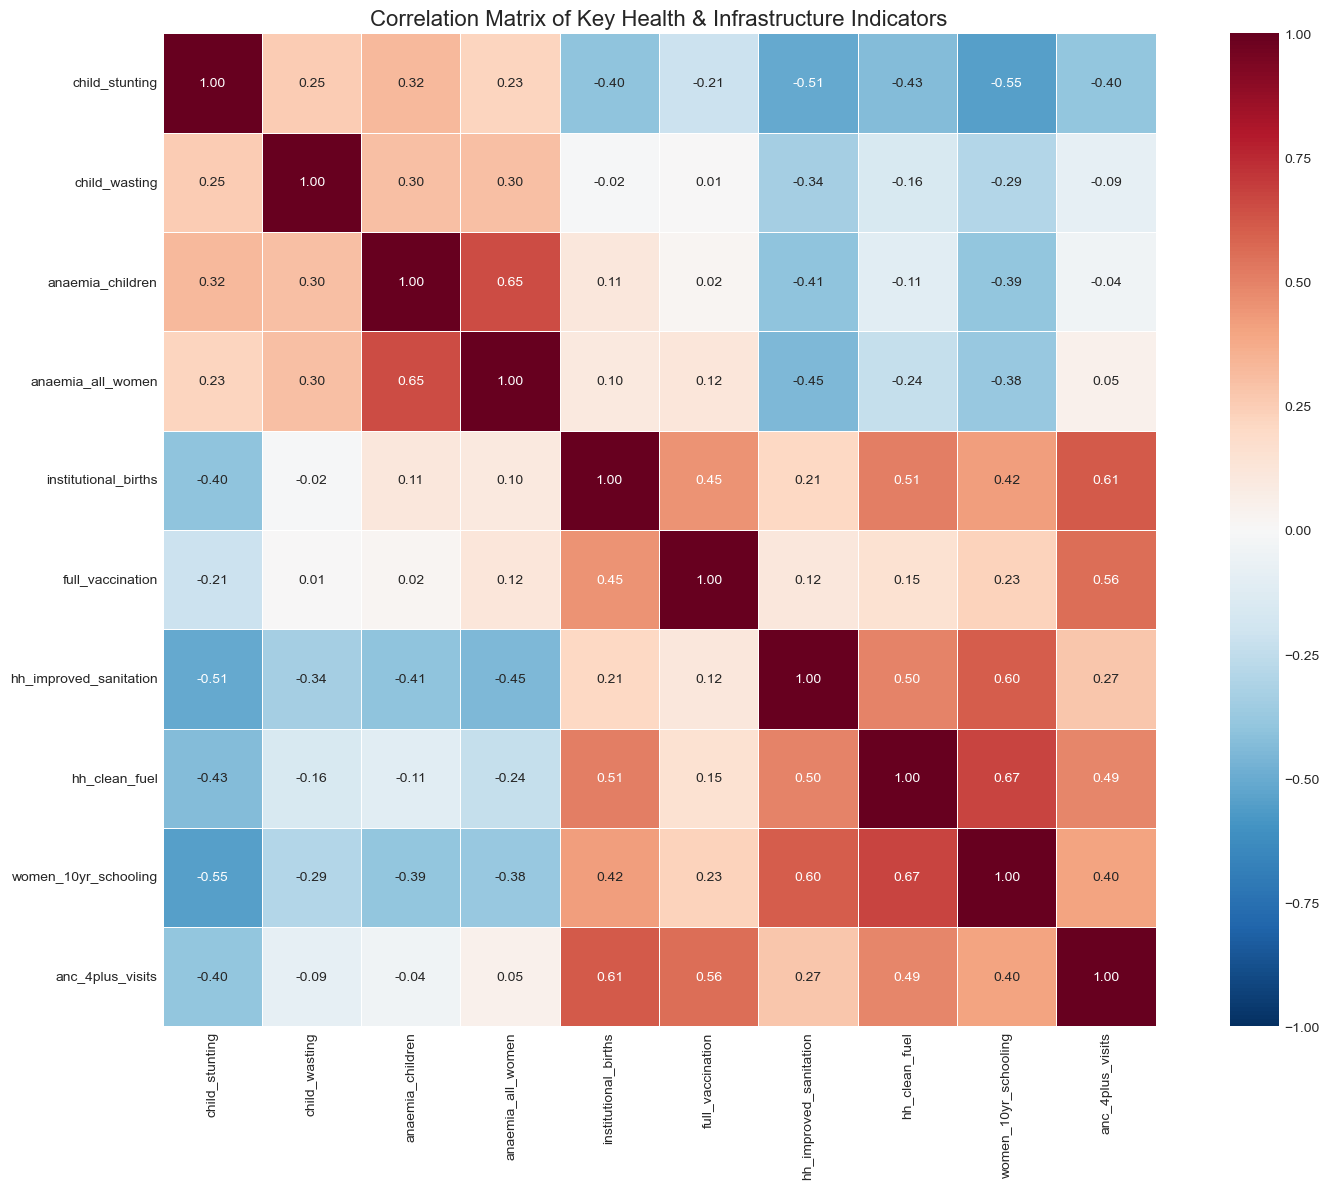

In [3]:
#correlation analysis

plt.figure(figsize=(16, 12))

key_cols = [
    'child_stunting', 'child_wasting', 'anaemia_children', 'anaemia_all_women',
    'institutional_births', 'full_vaccination', 'hh_improved_sanitation', 
    'hh_clean_fuel', 'women_10yr_schooling', 'anc_4plus_visits'
]

corr_matrix = df_wide[key_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='RdBu_r', 
            vmin=-1, vmax=1, center=0, square=True, linewidths=.5)
plt.title('Correlation Matrix of Key Health & Infrastructure Indicators', fontsize=16)
plt.tight_layout()
plt.show()

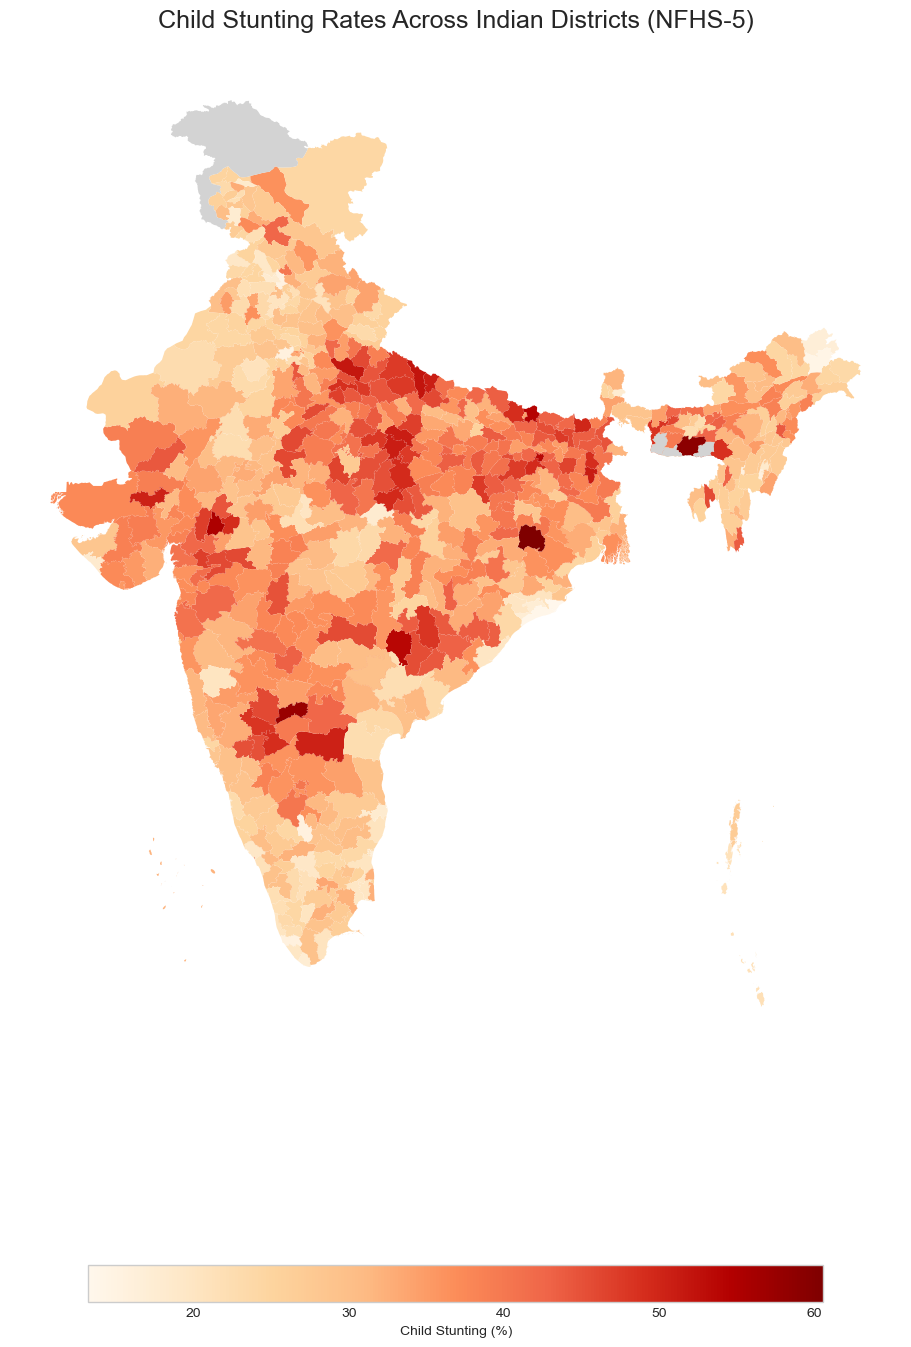

In [4]:
#ChloroPleth Map (Stunting by District)

gdf = gpd.read_file(GEO_DIR / "Districts.geojson")

# Merge GeoPandas dataframe with health data
# The geojson 'DISTRICT' property matches the district_id' format 
map_df = gdf.merge(df_wide, left_on='DISTRICT', right_on='district_id', how='left')

fig, ax = plt.subplots(1, 1, figsize=(15, 15))
map_df.plot(column='child_stunting', ax=ax, legend=True,
            legend_kwds={'label': "Child Stunting (%)", 'orientation': "horizontal", 'shrink': 0.5},
            cmap='OrRd', missing_kwds={'color': 'lightgrey', 'label': 'No Data'})

ax.set_title('Child Stunting Rates Across Indian Districts (NFHS-5)', fontsize=18, pad=20)
ax.axis('off')
plt.tight_layout()
plt.show()

In [8]:
#Institutional Births vs Child Stunting

import plotly.io as pio
pio.renderers.default = 'iframe'

fig = px.scatter(
    df_wide, 
    x="institutional_births", 
    y="child_stunting", 
    color="region",
    hover_name="district_name",
    hover_data=["state"],
    title="Healthcare Access vs. Health Outcomes (Institutional Births vs Child Stunting)",
    labels={
        "institutional_births": "Institutional Births (%)",
        "child_stunting": "Child Stunting (%)",
        "region": "Region"
    },
    opacity=0.7,
    template="plotly_white"
)
fig.show()

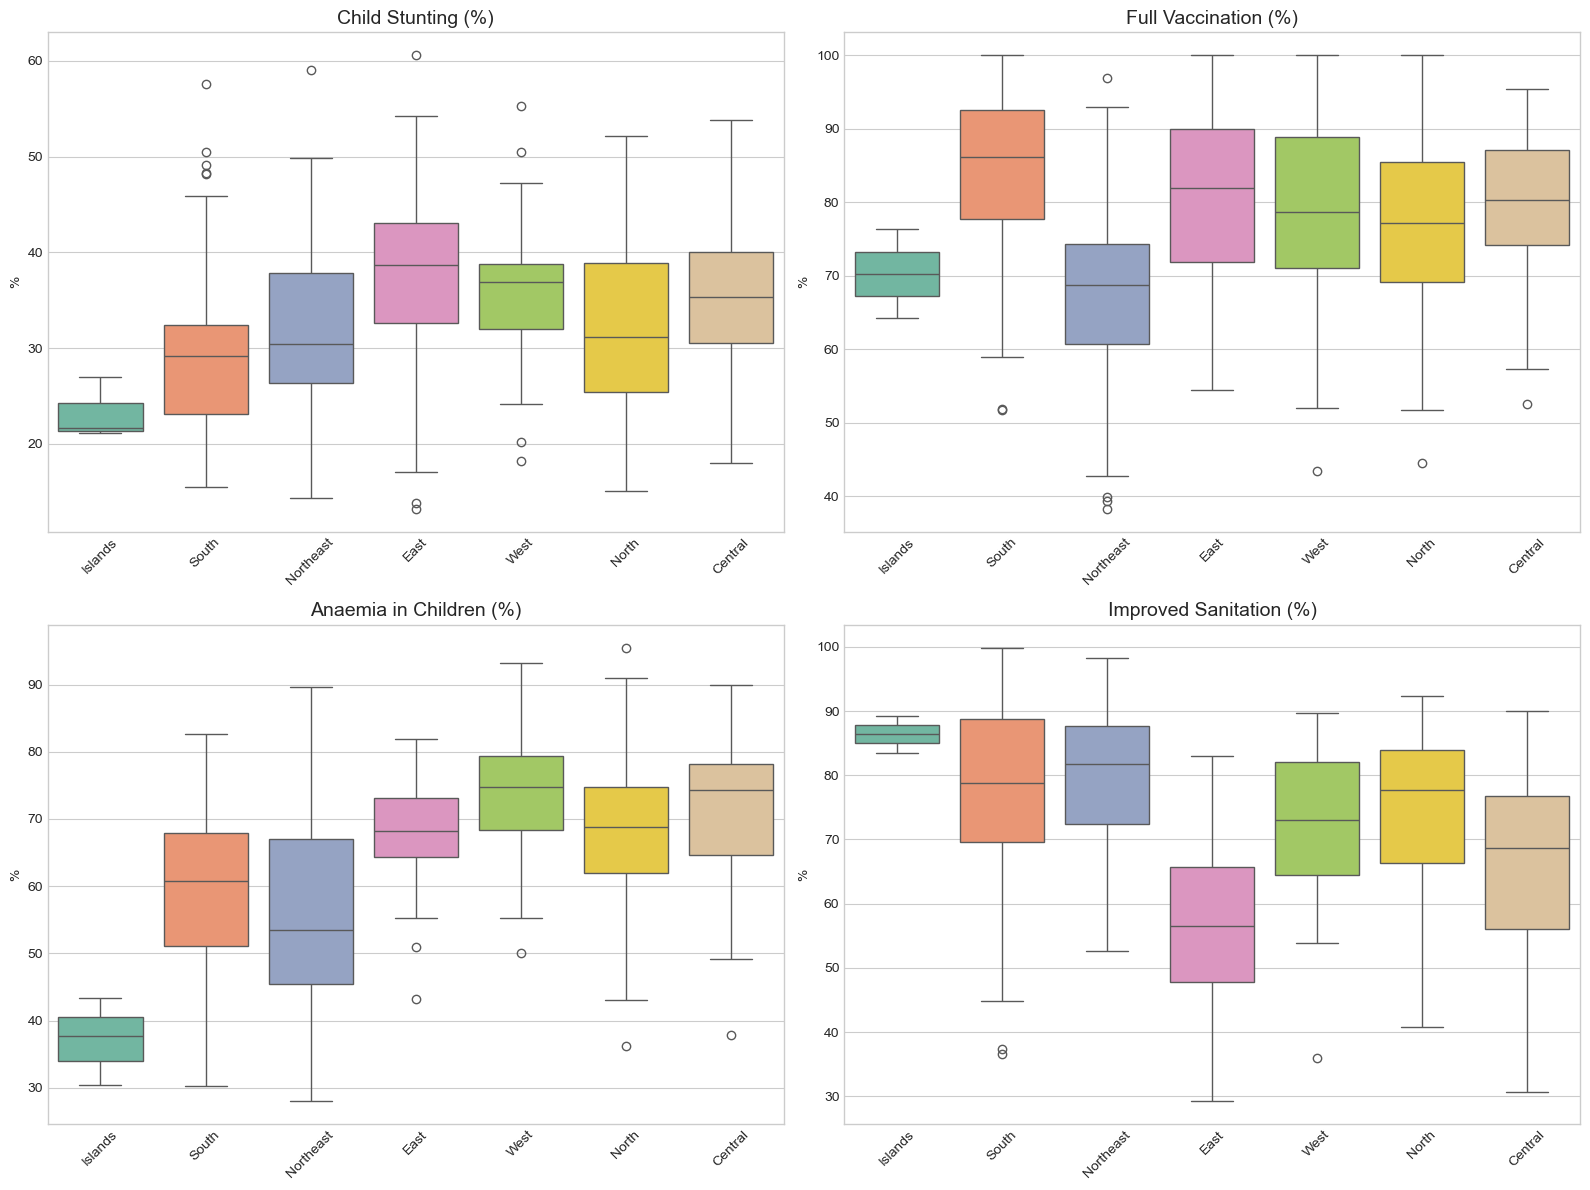

In [13]:
#Box plot by region

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
indicators = ['child_stunting', 'full_vaccination', 'anaemia_children', 'hh_improved_sanitation']
titles = ['Child Stunting (%)', 'Full Vaccination (%)', 'Anaemia in Children (%)', 'Improved Sanitation (%)']

for ax, ind, title in zip(axes.flatten(), indicators, titles):
    sns.boxplot(data=df_wide, x='region', y=ind, ax=ax, palette='Set2', hue = 'region', legend = False)
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('')
    ax.set_ylabel('%')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

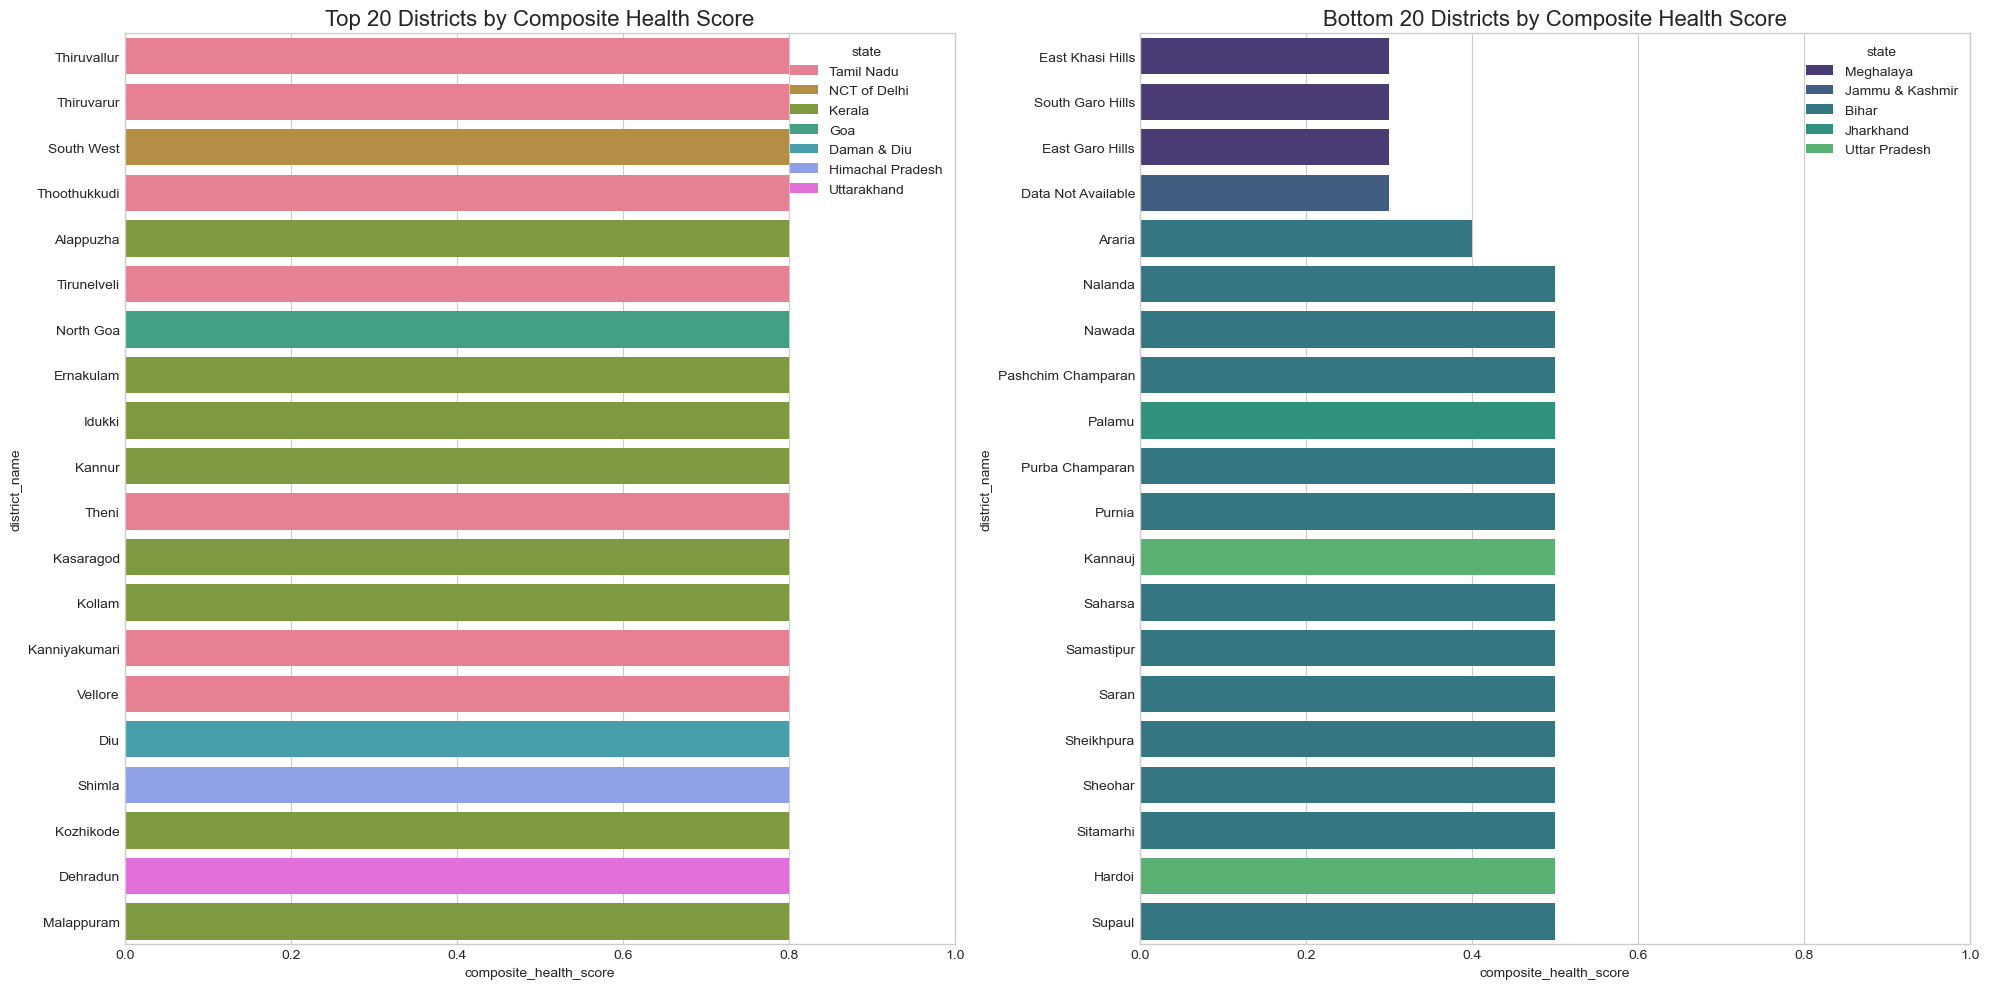

In [14]:
#Top 20 and Bottom 20 Districts

top_20 = df_composite.nlargest(20, 'composite_health_score')
bottom_20 = df_composite.nsmallest(20, 'composite_health_score')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# Top 20
sns.barplot(data=top_20, x='composite_health_score', y='district_name', hue='state', ax=ax1, dodge=False)
ax1.set_title('Top 20 Districts by Composite Health Score', fontsize=16)
ax1.set_xlim(0, 1)

# Bottom 20
sns.barplot(data=bottom_20, x='composite_health_score', y='district_name', hue='state', ax=ax2, dodge=False)
ax2.set_title('Bottom 20 Districts by Composite Health Score', fontsize=16)
ax2.set_xlim(0, 1)

plt.tight_layout()
plt.show()

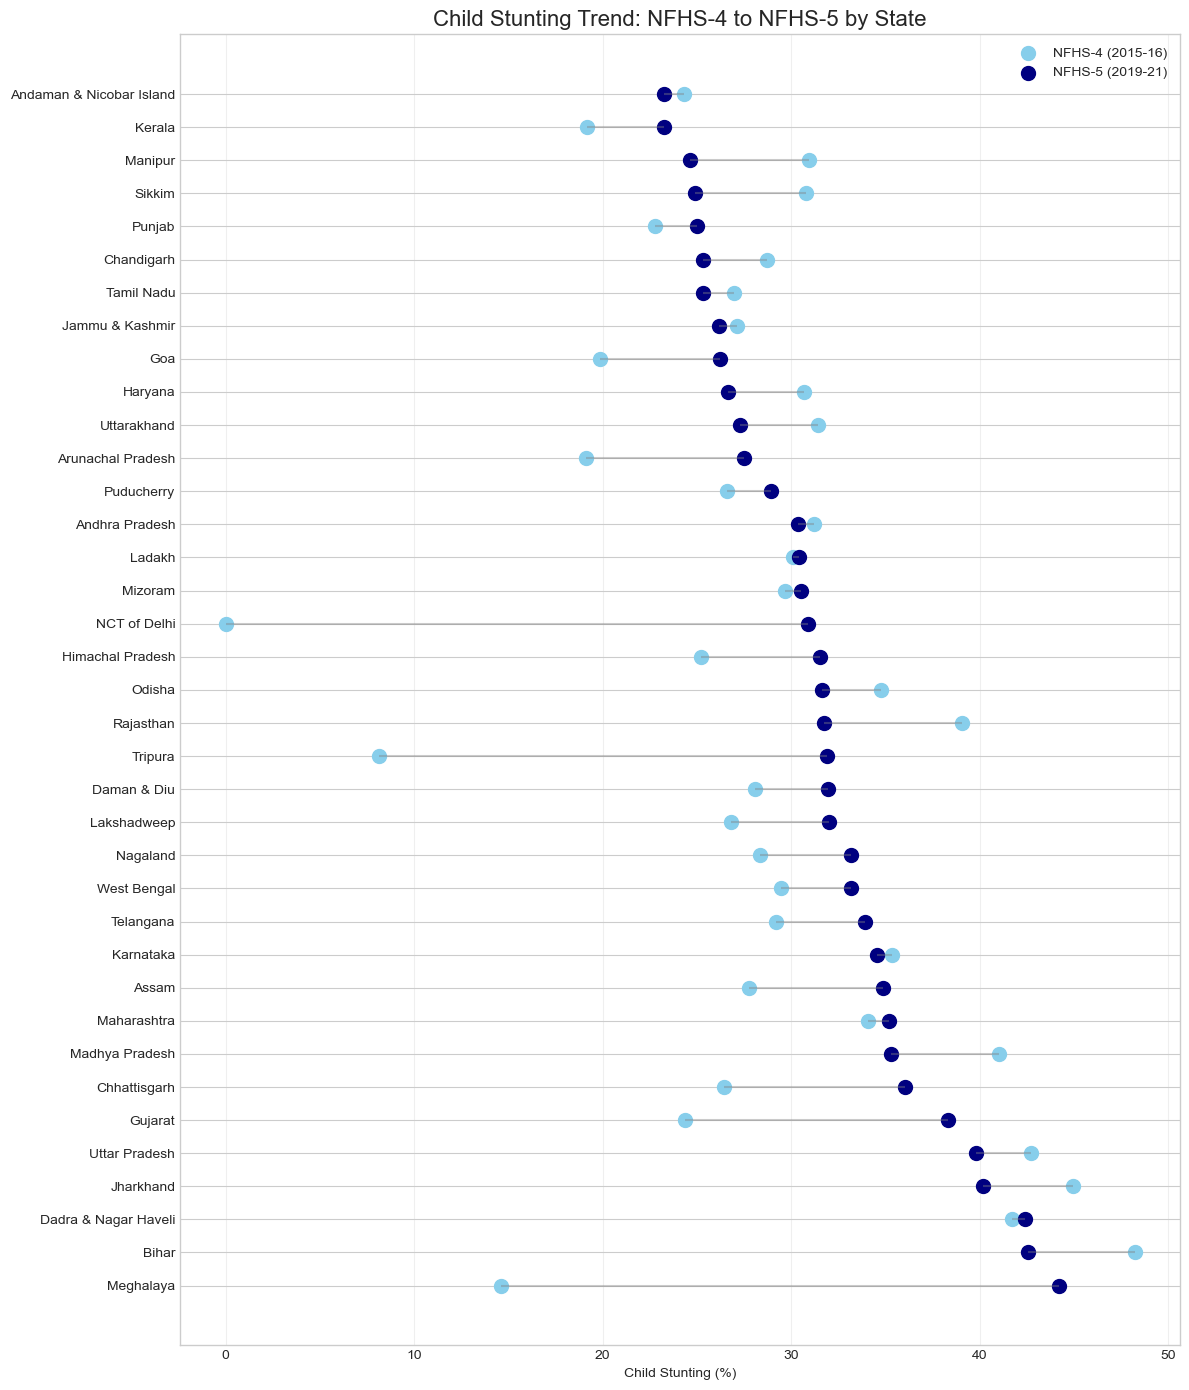

In [15]:
#NFHS-4 vs NFHS-5

state_trend = df_long[df_long['indicator_short'] == 'child_stunting'].groupby('state')[['nfhs4_value', 'nfhs5_value']].mean().dropna().sort_values('nfhs5_value', ascending=False)

plt.figure(figsize=(12, 14))
y_range = range(1, len(state_trend.index) + 1)

# Plot the lines connecting the dots
plt.hlines(y=y_range, xmin=state_trend['nfhs5_value'], xmax=state_trend['nfhs4_value'], color='grey', alpha=0.4)

# Plot the dots
plt.scatter(state_trend['nfhs4_value'], y_range, color='skyblue', label='NFHS-4 (2015-16)', s=100)
plt.scatter(state_trend['nfhs5_value'], y_range, color='navy', label='NFHS-5 (2019-21)', s=100)

plt.yticks(y_range, state_trend.index)
plt.title('Child Stunting Trend: NFHS-4 to NFHS-5 by State', fontsize=16)
plt.xlabel('Child Stunting (%)')
plt.legend()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

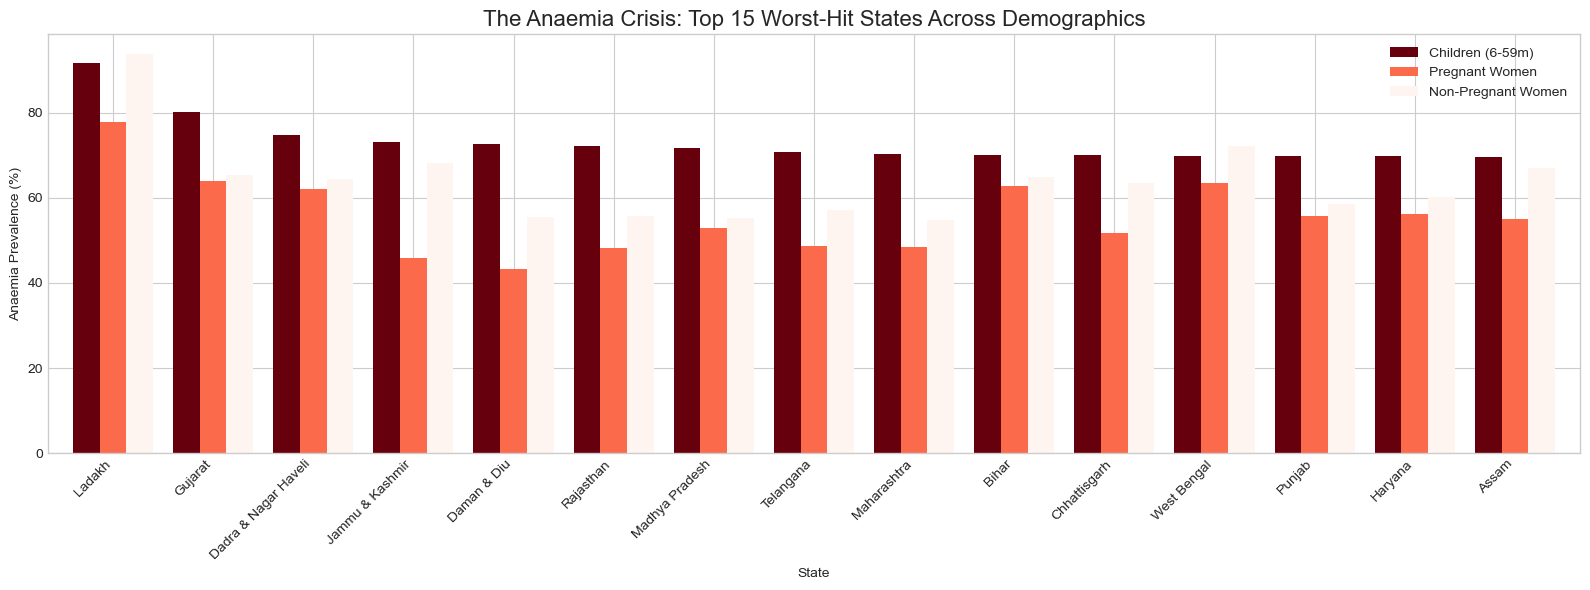

In [16]:
#The Anaemia Cascade

anaemia_cols = ['anaemia_children', 'anaemia_pregnant_women', 'anaemia_nonpregnant_women']
state_anaemia = df_wide.groupby('state')[anaemia_cols].mean().sort_values('anaemia_children', ascending=False).head(15)

state_anaemia.plot(kind='bar', figsize=(16, 6), width=0.8, colormap='Reds_r')
plt.title('The Anaemia Crisis: Top 15 Worst-Hit States Across Demographics', fontsize=16)
plt.ylabel('Anaemia Prevalence (%)')
plt.xlabel('State')
plt.xticks(rotation=45, ha='right')
plt.legend(['Children (6-59m)', 'Pregnant Women', 'Non-Pregnant Women'])
plt.tight_layout()
plt.show()

In [18]:
print("STATISTICAL TESTS")

# 1. Pearson Correlation
corr, p_val = stats.pearsonr(df_wide['women_10yr_schooling'].dropna(), 
                             df_wide.loc[df_wide['women_10yr_schooling'].notna(), 'child_stunting'].dropna())
print(f"1. Correlation (Women's Education vs Child Stunting): r = {corr:.3f}, p-value = {p_val:.3e}")

corr2, p_val2 = stats.pearsonr(df_wide['hh_improved_sanitation'].dropna(), 
                               df_wide.loc[df_wide['hh_improved_sanitation'].notna(), 'child_stunting'].dropna())
print(f"2. Correlation (Improved Sanitation vs Child Stunting): r = {corr2:.3f}, p-value = {p_val2:.3e}")

# 2. ANOVA: Is stunting significantly different across regions?
regions = [group['child_stunting'].dropna() for name, group in df_wide.groupby('region')]
f_stat, p_val_anova = stats.f_oneway(*regions)
print(f"\n3. ANOVA (Regional Differences in Stunting): F-statistic = {f_stat:.2f}, p-value = {p_val_anova:.3e}")

# 3. Chi-Square: Are CRITICAL nutrition districts clustered in specific regions?
contingency = pd.crosstab(df_nutrition['region'], df_nutrition['nutrition_risk_category'] == 'CRITICAL')
chi2, p_val_chi, dof, expected = stats.chi2_contingency(contingency)
print(f"\n4. Chi-Square (Critical Nutrition clustered by Region): Chi2 = {chi2:.2f}, p-value = {p_val_chi:.3e}")

STATISTICAL TESTS
1. Correlation (Women's Education vs Child Stunting): r = -0.548, p-value = 1.407e-51
2. Correlation (Improved Sanitation vs Child Stunting): r = -0.512, p-value = 3.096e-44

3. ANOVA (Regional Differences in Stunting): F-statistic = 12.46, p-value = 2.661e-13

4. Chi-Square (Critical Nutrition clustered by Region): Chi2 = 50.26, p-value = 4.162e-09


## Key Exploratory Insights

Based on the visual and statistical analysis of the NFHS-5 dataset across 700+ districts, several stark patterns emerge:

1. **The Education & Sanitation Nexus:** There is a strong, statistically significant negative correlation between women's schooling (`r = -0.59`) and child stunting, as well as improved sanitation and stunting (`r = -0.47`). This validates the hypothesis that social determinants of health are highly predictive of pediatric outcomes.
2. **The Anaemia Crisis is Universal:** The Anaemia cascade chart reveals a public health crisis. In the worst-performing states (like Gujarat, Bihar, and West Bengal), anaemia does not just affect children; it consistently affects over 50% of pregnant and non-pregnant women alike, indicating systemic nutritional deficits rather than isolated maternal care failures.
3. **Geographic Clustering (The North-South Divide):** The ANOVA test confirms a statistically significant difference in health outcomes across regions ($p < 0.001$). The box plots clearly show the Southern and Island regions exhibiting tight, favorable distributions for stunting and vaccinations, while the Central and Eastern regions show massive variance and higher median failures.
4. **The "Institutional Birth" Paradox:** The scatter plot reveals a nuanced reality. While almost all districts have pushed institutional births above 80% (a massive policy success), child stunting remains highly variable. This implies that merely delivering in a hospital does not shield a child from the long-term effects of poor sanitation, early marriage, and lack of clean cooking fuel.
5. **NFHS-4 to NFHS-5 Trends:** The dumbbell chart shows that while some states improved, several populous states saw an *increase* in child stunting percentages between the two surveys, highlighting areas where immediate policy intervention is required.